In [34]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END,add_messages
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import BaseModel,Field
from langchain_community.vectorstores import FAISS
from langchain_community.tools.tavily_search import TavilySearchResults

In [ ]:
loader1 = PyPDFLoader("documents/book1.pdf")
loader2 = PyPDFLoader("documents/book2.pdf")
loader3 = PyPDFLoader("documents/book3.pdf")

In [ ]:
docs = loader1.load() + loader2.load() + loader3.load()
len(docs)

In [ ]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap = 200
)

chunk = splitter.split_documents(docs)

len(chunk)

In [ ]:
load_dotenv()

model = ChatOpenAI()

In [ ]:
embedding = OpenAIEmbeddings()

parser = StrOutputParser()

vector_store = FAISS.from_documents(
        embedding=embedding,
        documents=chunk
)

In [ ]:
retriever = vector_store.as_retriever(
    search_type = 'mmr',
    serach_kwargs = {'k':4}
)

In [112]:
class RagState(TypedDict,total=False):

    question : str
    documents : List[Document]

    good_docs : List[Document]
    verdict : str
    reason : str

    strip : List[str]
    kept_strip : List[str]
    refined_content : str

    web_docs : List[Document]

    answer : str

In [113]:
class KeepOrDrop(BaseModel):

    keep : bool = Field(description='True or False')

parser1 = PydanticOutputParser(pydantic_object=KeepOrDrop)

In [114]:
def retrieve(state:RagState)->dict:

    question = state['question']

    response = retriever.invoke(question)

    return {'documents':response}

In [115]:
import re

def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [130]:
def refine(state:RagState)->dict:

    #refined_content = state.get('refined_content',"")

    question = state['question']

    #documents = state['documents']
    good_docs = state['good_docs']
    web_docs = state.get('web_docs','')
    verdict = state['verdict']

    if verdict == 'CORRECT':
        context = '\n'.join(f"- {docs.page_content}" for docs in good_docs)
    else:
        context = '\n'.join(f"- {docs.page_content}" for docs in web_docs)

    strips = decompose_to_sentences(context)

    template = ChatPromptTemplate([
        ('system',
         "You are a strict relevance filter.\n"
        "Return keep=true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentence. Output JSON only. \n"),
        ('user',"Question: {question}\n\nSentence:\n{sentence}")
    ],
    input_variables = ['question','sentence'],
    )

    kept : List[str] =[]

    model_with_structured_output = model.with_structured_output(KeepOrDrop)
    chain = template | model_with_structured_output 
    for s in strips:
        keep_drop : KeepOrDrop = chain.invoke({'question':question,'sentence':s})
        #keep_drop_dict = keep_drop.model_dump()
        if keep_drop.keep:
            kept.append(s)

    refined_content = ''.join(kept).strip()

    return {
        'strips':strips,
        'keep_strip':kept,
        'refined_content':refined_content
    }

In [131]:
def generate(state:RagState)->dict:

    question = state['question']
    refined_content = state['refined_content']
    
    template = ChatPromptTemplate([
        ('system',"You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'"),
        ('user',"Question: {question}\n\nRefined context:\n{refined_content}")
    ],
    input_variables = ['question','refined_context']
    )

    chain = template | model | parser

    response = chain.invoke({'question':question,'refined_content':refined_content})

    return {'answer':response}

In [132]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [133]:
class DocEvalScore(BaseModel):

    score : float
    reason : str

#parser2 = PydanticOutputParser(pydantic_object=DocEvalScore)

template = ChatPromptTemplate([
    ('system',"You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only. \n"),
    ('human',"Question: {question}\n\nChunk:\n{chunk}")
],
input_variables = ['question','chunk'],
)

model_with_structured_output = model.with_structured_output(DocEvalScore)

chain = template | model_with_structured_output 

def eval_each_node(state:RagState)->dict:

    question = state['question']
    documents = state['documents']

    score : List[float] = []
    reason : List[str] = []
    good_docs : List[Document] = []

    for doc in documents:
        doc_eval_score : DocEvalScore = chain.invoke({'question':question,'chunk':doc.page_content})
        #doc_eval_score_dict = doc_eval_score.model_dump()
        score.append(doc_eval_score.score)
        reason.append(doc_eval_score.reason)

        if doc_eval_score.score > LOWER_TH:
            good_docs.append(doc)

    if any(s > UPPER_TH for s in score):
        return {
            'good_docs':good_docs,
            'verdict':'CORRECT',
            'reason': f"At least one doc score is greater that {UPPER_TH}"
        }
    
    if len(score)>0 and all(s<LOWER_TH for s in score):
        return {
            'good_docs':[],
            'verdict':'INCORRECT',
            'reason': f"All doc score is less than {LOWER_TH}"
        }
    
    return {
        'good_docs':good_docs,
        'verdict':'AMBIGUOUS',
        'reason': f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}"
    }

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_openai\chat_models\base.py:2181: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [134]:
def conditional_edge(state : RagState)->dict:
    verdict = state['verdict']

    if verdict == 'CORRECT':
        return "refine"
    elif verdict == 'INCORRECT':
        return "web_search"
    else:
        return "ambiguous"

def ambiguous(state:RagState)->dict:
    reason = state['reason']
    return {'answer':f"Ambiguous {reason}"}


In [135]:
tavily = TavilySearchResults(max_results=5)

def web_search(state:RagState)->dict:
    
    question = state['question']

    results = tavily.invoke({'query':question})

    web_docs = []
    for r in results or []:

        title = r.get('title','')
        url = r.get('url','')
        content = r.get('content','')

        text = f"TITLE : {title}\n\nURL: {url} \nCONTENT: {content}"

        web_docs.append(Document(page_content=text,metadata={'url':url,'title':title}))

    print([doc.page_content for doc in web_docs])

    return {'web_docs':web_docs}

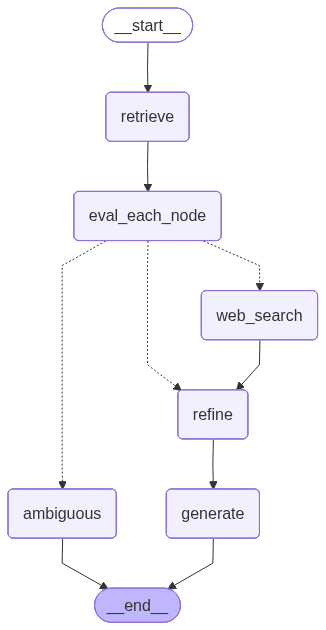

In [136]:
graph = StateGraph(RagState)
graph.add_node('retrieve',retrieve)
graph.add_node('refine',refine)
graph.add_node('generate',generate)
graph.add_node('eval_each_node',eval_each_node)
graph.add_node('ambiguous',ambiguous)
graph.add_node('web_search',web_search)

graph.add_edge(START,'retrieve')
graph.add_edge('retrieve','eval_each_node')
graph.add_conditional_edges('eval_each_node',conditional_edge,{'ambiguous':'ambiguous','web_search':'web_search','refine':'refine'})
graph.add_edge('web_search','refine')
graph.add_edge('refine','generate')
graph.add_edge('generate',END)
graph.add_edge('ambiguous',END)

chatbot = graph.compile()

chatbot

In [139]:
response = chatbot.invoke({'question':'recipe of biryani?'})

print(response)

['TITLE : Best and Easy Chicken Biryani Recipe | How to Make Biryani\n\nURL: https://www.cookwithkushi.com/best-easy-chicken-biryani-recipe/ \nCONTENT: Add onion, tomato, coriander leaves, mint leaves, tandoori masala, and give it a good mix. Cook this for a minute. Now spread it evenly to cover the base of the pan.\n\nAdd partially cooked rice, spread evenly, and garnish with some more mint and coriander leaves.\n\nFinally, add butter and sprinkle some more tandoori masala powder or biryani masala powder and splash ¼ cup of water. Cover this and cook on low flame for 20 minutes or until rice is cooked through thoroughly.\n\nTips: [...] ## What is chicken biryani?\n\nBiryani is a popular rice dish made with aromatic Indian spices either with the meat of your choice (chicken, beef, goat, lamb, fish, prawns) or eggs or vegetables (potato, mushroom, baby corn, cauliflower, paneer, etc.).\n\nFirst, the meat (or eggs or vegetables) and the rice are cooked separately. Then, they are arranged

In [140]:
print(response['verdict'])
print('*'*100)
print(response['reason'])
print('*'*100)
print(response['answer'])

INCORRECT
****************************************************************************************************
All doc score is less than 0.3
****************************************************************************************************
Here is the recipe of chicken biryani:

Ingredients:
- 2 Onions, chopped lengthwise
- 5 to 6 Garlic cloves, finely chopped
- 1 inch Ginger, finely chopped
- 2 to 3 Green chilies, slit
- 2 Tomatoes, diced
- 6 to 8 strands Coriander leaves
- ¼ cup Mint leaves
- 1 ½ tablespoon Oil
- 1 inch Cinnamon stick
- 3 to 4 Cardamom pods
- 3 to 4 Cloves
- 2 Bay leaf
- 1 teaspoon Cumin seeds
- 1 tablespoon Biryani or Tandoori Masala
- 1 tablespoon Butter or ghee
- ¼ cup Water

Instructions:
1. Marinate the chicken with a mixture of vegetable oil, garlic, ginger, serrano chili pepper, mint, cilantro, garam masala, cinnamon, and salt.
2. Caramelize onions in ghee, then add the marinated chicken.
3. Parboil the rice with spices separately and strain.
4. Layer the r